In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# I add the project root to the system path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
# I load the scaled pixel data that I generated in features.py
processed_dir = os.path.join(project_root, "data", "processed")
input_path = os.path.join(processed_dir, "fashion_mnist_scaled.csv")

df = pd.read_csv(input_path)

# I sample just 1,000 rows so this notebook runs quickly
df_subset = df.sample(n=1000, random_state=42).reset_index(drop=True)

pixel_cols = [col for col in df.columns if col.startswith('pixel')]
X_subset = df_subset[pixel_cols]
categories_subset = df_subset['category']

Running t-SNE with perplexity=5...
Running t-SNE with perplexity=30...
Running t-SNE with perplexity=50...
Running t-SNE with perplexity=100...


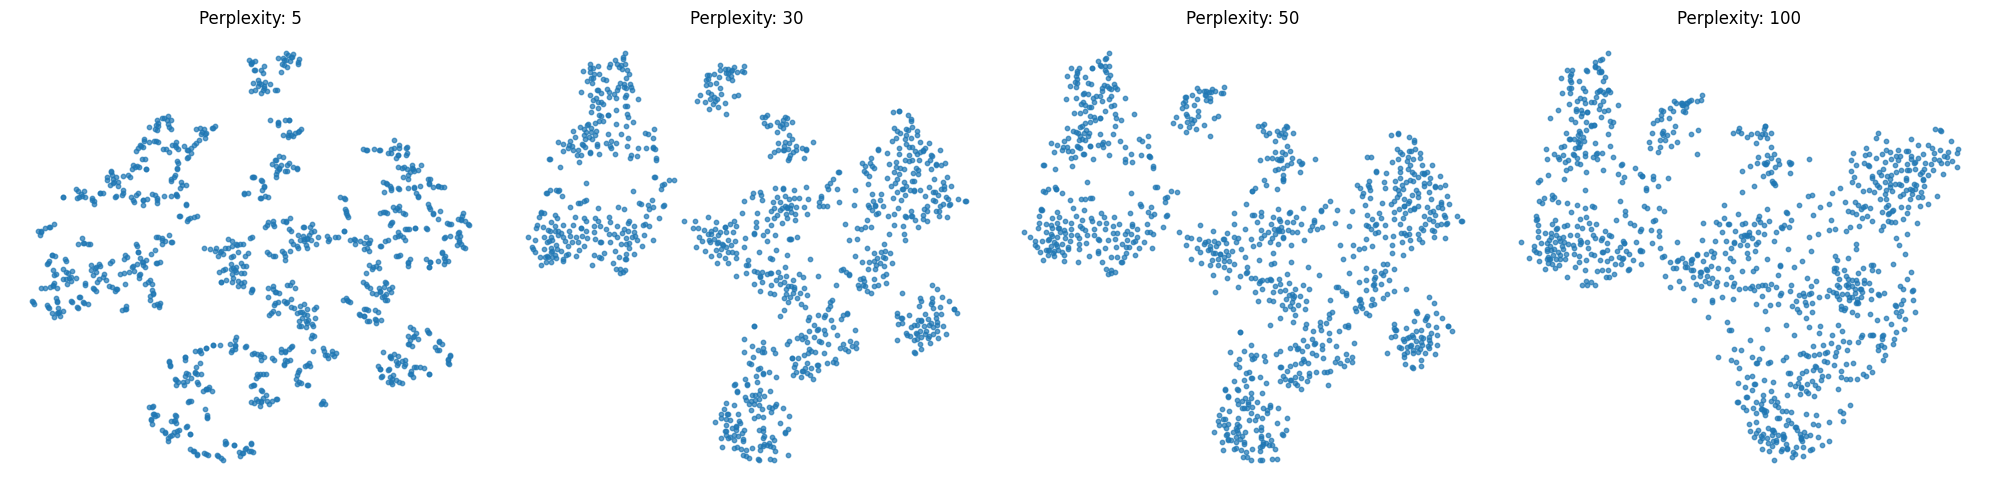

In [3]:
# I define a list of perplexity values to test
perplexities = [5, 30, 50, 100]

# I create a figure with subplots for each perplexity value
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# I loop through each value, run t-SNE, and plot the result
for i, p in enumerate(perplexities):
    print(f"Running t-SNE with perplexity={p}...")
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    tsne_results = tsne.fit_transform(X_subset)

    # I plot the X and Y coordinates
    axes[i].scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.7)
    axes[i].set_title(f"Perplexity: {p}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()